In [44]:
import pandas as pd

# Load data from yahoo fincance to a dataframe
import yfinance as yf

tickers = [
    "SBK.JO","FSR.JO","ABG.JO","NED.JO",
    "AGL.JO","IMP.JO",
    "SHP.JO","PIK.JO","WHL.JO",
    "MTN.JO","VOD.JO",
    "BVT.JO","REM.JO",
    "SOL.JO","NPN.JO","PRX.JO"
]

df = yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]

# Display the first 5 rows and info of the DataFrame
display(df.head())
df.info()

/tmp/ipykernel_9131/1548661118.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  16 of 16 completed


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
Date,,,,,,,,,,,,,,,,
2020-01-02,15004.890625,39658.972656,20505.820312,6302.159668,14288.040039,8347.368164,21655.148438,46741.820312,6377.471680,49022.402344,13958.859375,16812.162109,12502.415039,30347.042969,11561.833008,4938.207031
2020-01-03,14897.349609,39601.367188,20518.791016,6208.500488,14799.537109,8105.876953,21479.923828,47071.761719,6338.523438,48957.710938,13930.948242,16656.791016,12349.688477,31161.023438,11544.890625,4929.227051
2020-01-06,14474.157227,39232.292969,20261.347656,5983.315918,14577.189453,8022.054688,21061.773438,46867.792969,6148.777832,48861.820312,13686.910156,16273.336914,11976.367188,31795.232422,11368.503906,4777.558594
2020-01-07,14097.766602,39118.050781,20364.125000,6018.189941,14457.541992,8023.052734,21205.140625,47153.746094,6236.659668,49568.355469,13715.536133,16286.286133,12178.000000,31495.607422,11470.151367,4794.521484
2020-01-08,14234.183594,39172.738281,20448.941406,6014.203613,15245.227539,7944.219727,20889.537109,46491.863281,6246.646973,49409.152344,13703.371094,16369.951172,12206.947266,31103.095703,11460.185547,4871.353027


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1500 entries, 2020-01-02 to 2025-12-31
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ABG.JO  1500 non-null   float64
 1   AGL.JO  1500 non-null   float64
 2   BVT.JO  1500 non-null   float64
 3   FSR.JO  1500 non-null   float64
 4   IMP.JO  1500 non-null   float64
 5   MTN.JO  1500 non-null   float64
 6   NED.JO  1500 non-null   float64
 7   NPN.JO  1500 non-null   float64
 8   PIK.JO  1500 non-null   float64
 9   PRX.JO  1500 non-null   float64
 10  REM.JO  1500 non-null   float64
 11  SBK.JO  1500 non-null   float64
 12  SHP.JO  1500 non-null   float64
 13  SOL.JO  1500 non-null   float64
 14  VOD.JO  1500 non-null   float64
 15  WHL.JO  1500 non-null   float64
dtypes: float64(16)
memory usage: 199.2 KB


In [45]:
# Calculate daily returns (already available in the DataFrame)
daily_returns = np.log(df / df.shift(1)).dropna()

# Annualized metrics
annual_returns = daily_returns.mean() * 252
annual_cov_matrix = daily_returns.cov() * 252

# Calculate annualized average returns
annual_returns = daily_returns.mean() * 252  # 252 trading days in a year

# Calculate annualized covariance matrix
annual_cov_matrix = daily_returns.cov() * 252

print("Annualized Average Returns:")
display(annual_returns)

print("\nAnnualized Covariance Matrix:")
display(annual_cov_matrix)

Annualized Average Returns:


,0
Ticker,
ABG.JO,0.078452
AGL.JO,0.091895
BVT.JO,0.024648
FSR.JO,0.061248
IMP.JO,0.101901
MTN.JO,0.119034
NED.JO,0.034671
NPN.JO,0.144565
PIK.JO,-0.158108



Annualized Covariance Matrix:


Ticker,ABG.JO,AGL.JO,BVT.JO,FSR.JO,IMP.JO,MTN.JO,NED.JO,NPN.JO,PIK.JO,PRX.JO,REM.JO,SBK.JO,SHP.JO,SOL.JO,VOD.JO,WHL.JO
Ticker,,,,,,,,,,,,,,,,
ABG.JO,0.129268,0.041176,0.060645,0.088135,0.051302,0.068920,0.109141,0.014540,0.032389,0.005345,0.063682,0.107163,0.040523,0.089660,0.011313,0.062013
AGL.JO,0.041176,0.166481,0.027376,0.041103,0.126672,0.049141,0.042809,0.040871,0.023985,0.041386,0.032814,0.040545,0.018225,0.117015,0.021175,0.030252
BVT.JO,0.060645,0.027376,0.093230,0.056582,0.042695,0.046353,0.066244,0.010697,0.029886,0.005143,0.048045,0.071152,0.038370,0.056110,0.016796,0.054372
FSR.JO,0.088135,0.041103,0.056582,0.106006,0.048227,0.064194,0.091460,0.016139,0.033575,0.007652,0.061184,0.098356,0.040178,0.071161,0.019978,0.053472
IMP.JO,0.051302,0.126672,0.042695,0.048227,0.375352,0.067998,0.063647,0.050623,0.027160,0.046160,0.045150,0.114433,0.027370,0.160480,-0.019235,0.046854
MTN.JO,0.068920,0.049141,0.046353,0.064194,0.067998,0.198158,0.074894,0.020152,0.032629,0.014609,0.054693,0.074064,0.035774,0.115072,0.033232,0.050769
NED.JO,0.109141,0.042809,0.066244,0.091460,0.063647,0.074894,0.143063,0.013994,0.032649,0.003555,0.068394,0.109496,0.041869,0.104447,0.002790,0.066421
NPN.JO,0.014540,0.040871,0.010697,0.016139,0.050623,0.020152,0.013994,0.175850,0.014974,0.154443,0.017788,-0.011079,0.008622,0.027501,-0.000240,0.021693
PIK.JO,0.032389,0.023985,0.029886,0.033575,0.027160,0.032629,0.032649,0.014974,0.147027,0.010809,0.028658,0.034282,0.047914,0.031567,0.052655,0.043874


In [54]:
import numpy as np

num_assets = len(annual_returns)
num_portfolios = 50000  # Number of random portfolios to simulate

# Initialize arrays to store portfolio metrics
all_weights = np.zeros((num_portfolios, num_assets))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

In [48]:
# Simulate random portfolios
for x in range(num_portfolios):
    weights = np.array(np.random.random(num_assets))
    weights = weights / np.sum(weights)

    # Save weights
    all_weights[x, :] = weights

    # Calculate portfolio return
    ret_arr[x] = np.sum((weights * annual_returns)) * 1

    # Calculate portfolio volatility
    vol_arr[x] = np.sqrt(np.dot(weights.T, np.dot(annual_cov_matrix, weights))) * 1

    # Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity, common in these examples)
    sharpe_arr[x] = ret_arr[x] / vol_arr[x]

In [49]:
max_sharpe_idx = sharpe_arr.argmax()

max_sharpe_ret = ret_arr[max_sharpe_idx]
max_sharpe_vol = vol_arr[max_sharpe_idx]
max_sharpe_weights = all_weights[max_sharpe_idx]

print("Maximum Sharpe Ratio:", sharpe_arr[max_sharpe_idx])
print("Portfolio Return (Max Sharpe):")
display(max_sharpe_ret)
print("Portfolio Volatility (Max Sharpe):")
display(max_sharpe_vol)
print("Portfolio Weights (Max Sharpe):")
display(pd.Series(max_sharpe_weights, index=df.columns))

Maximum Sharpe Ratio: 0.40051867962151166
Portfolio Return (Max Sharpe):


np.float64(0.09069827518903492)

Portfolio Volatility (Max Sharpe):


np.float64(0.22645204781645734)

Portfolio Weights (Max Sharpe):


,0
Ticker,
ABG.JO,0.092142
AGL.JO,0.023726
BVT.JO,0.048296
FSR.JO,0.141748
IMP.JO,0.045419
MTN.JO,0.081182
NED.JO,0.075039
NPN.JO,0.095551
PIK.JO,0.007108


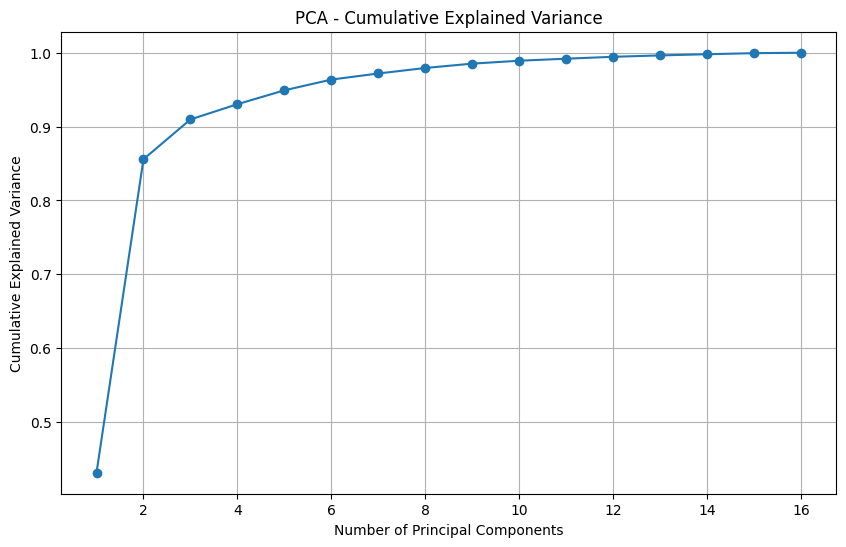

Top loadings for PC1 (Market Factor):
Ticker
SBK.JO    0.931876
VOD.JO    0.360376
ABG.JO    0.015690
NED.JO    0.015687
IMP.JO    0.015541
FSR.JO    0.014839
MTN.JO    0.012540
SOL.JO    0.011223
Name: PC1, dtype: float64


In [56]:

from sklearn.decomposition import PCA
import seaborn as sns

# Use daily returns
returns = np.log(df / df.shift(1)).dropna()

# Fit PCA
pca = PCA()
pca.fit(returns)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Top loadings for first few components
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df.columns))],
    index=df.columns
)

print("Top loadings for PC1 (Market Factor):")
print(loadings['PC1'].abs().sort_values(ascending=False).head(8))

The Principal Component Analysis helps us understand which combination of assets contributes most to the overall risk (volatility) of the portfolio. The first few principal components often explain a large portion of the total variance, indicating the main drivers of risk.

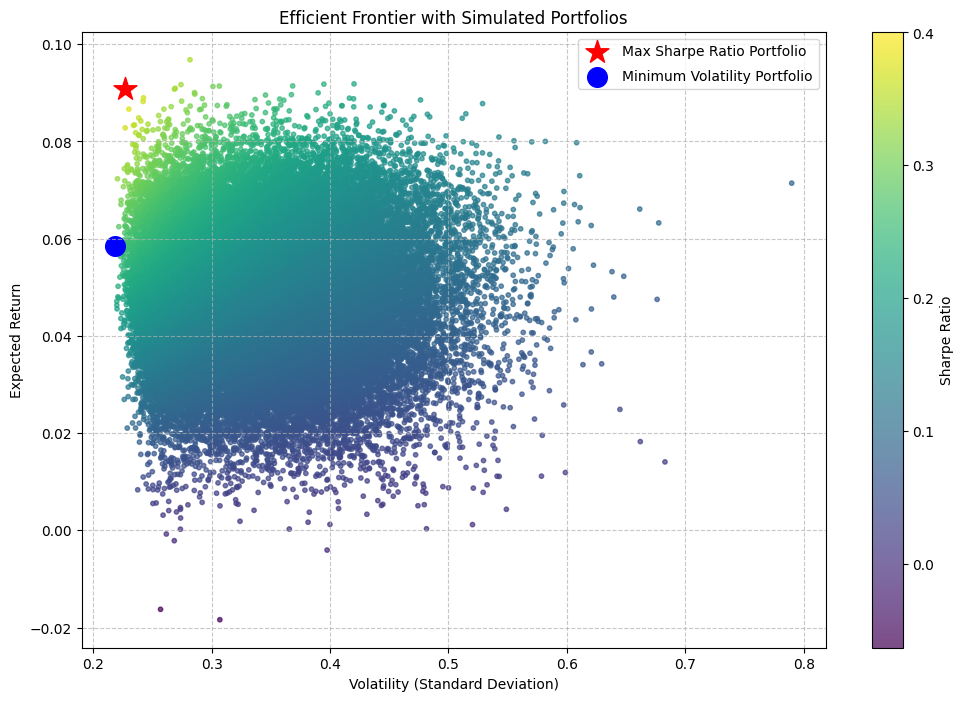

In [51]:
# Create a scatter plot of all simulated portfolios
plt.figure(figsize=(12, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Simulated Portfolios')

# Mark the portfolio with the maximum Sharpe Ratio
plt.scatter(max_sharpe_vol, max_sharpe_ret, c='red', marker='*', s=300, label='Max Sharpe Ratio Portfolio')

# Find and mark the minimum volatility portfolio
min_vol_idx = vol_arr.argmin()
min_vol_ret = ret_arr[min_vol_idx]
min_vol_vol = vol_arr[min_vol_idx]
plt.scatter(min_vol_vol, min_vol_ret, c='blue', marker='o', s=200, label='Minimum Volatility Portfolio')

plt.legend(labelspacing=0.8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [52]:
allocation_for_100 = pd.Series(max_sharpe_weights * 100, index=df.columns)
print("Allocation for R100 based on Max Sharpe Ratio weights:")
display(allocation_for_100)

Allocation for R100 based on Max Sharpe Ratio weights:


,0
Ticker,
ABG.JO,9.214249
AGL.JO,2.372610
BVT.JO,4.829600
FSR.JO,14.174785
IMP.JO,4.541902
MTN.JO,8.118163
NED.JO,7.503855
NPN.JO,9.555146
PIK.JO,0.710833


The plot above visualizes the efficient frontier. Each point represents a simulated portfolio, with its return plotted against its volatility. The color gradient indicates the Sharpe Ratio. The red star marks the portfolio with the highest Sharpe Ratio (our optimal risk-adjusted portfolio), and the blue circle indicates the portfolio with the minimum volatility among all simulated portfolios.

In [53]:
min_sharpe_weights = all_weights[sharpe_arr.argmin()]
allocation_for_100 = pd.Series(min_sharpe_weights * 100, index=df.columns)
print("Allocation for R100 based on Max Sharpe Ratio weights:")
display(allocation_for_100)

Allocation for R100 based on Max Sharpe Ratio weights:


,0
Ticker,
ABG.JO,0.552358
AGL.JO,4.255403
BVT.JO,16.014491
FSR.JO,9.311784
IMP.JO,2.006915
MTN.JO,0.241043
NED.JO,5.685298
NPN.JO,5.067807
PIK.JO,16.477133
